In [1]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X,y = load_digits(return_X_y=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("images -", X.shape[0])
print("features -", X.shape[1])
print("digit present -", sorted(set(y)))

images - 1797
features - 64
digit present - [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [3]:
print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)

Original Shape: (1797, 64)
Scaled Shape: (1797, 64)


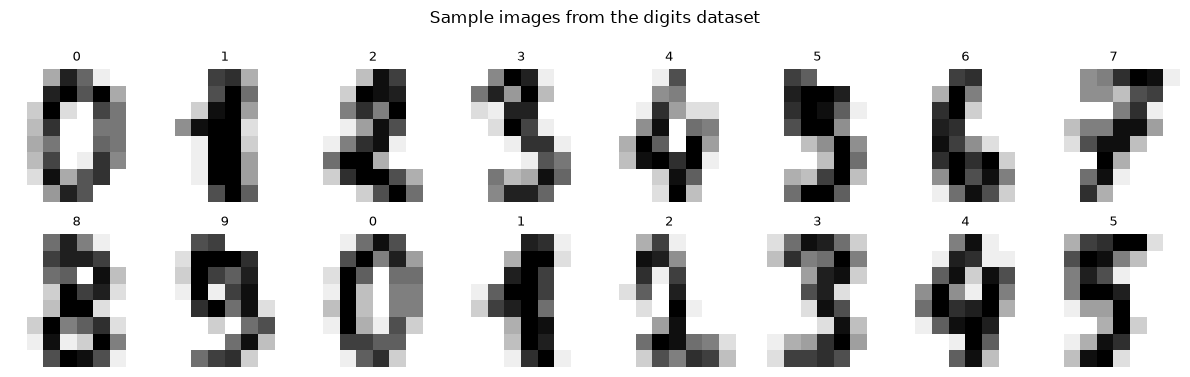

In [4]:
# Display digit images
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(y[i]), fontsize=9)
    ax.axis("off")

plt.suptitle("Sample images from the digits dataset")
plt.tight_layout()
plt.show()

# **Part A — Why reduce at all**
## **TASK 01 — Demonstrate the curse of dimensionality**

In [5]:
rng = np.random.default_rng(0)
dimentions = [2, 10, 50, 200, 1000]

results = []

for d in dimentions:
    pts = rng.random((500, d))
    dists = np.linalg.norm(pts[0] - pts[1:], axis=1)
    near, far = dists.min(), dists.max()
    ratio = near / far

    results.append([d, near, far, ratio])

table = pd.DataFrame(results, 
                    columns=["Dimension", "Nearest Distance", "Farthest Distance", "Ratio"])

table.round(4)

,Dimension,Nearest Distance,Farthest Distance,Ratio
0,2,0.0140,0.9368,0.0149
1,10,0.5783,1.9176,0.3016
2,50,2.2644,3.9437,0.5742
3,200,5.0720,6.1328,0.8270
4,1000,12.2594,13.4750,0.9098


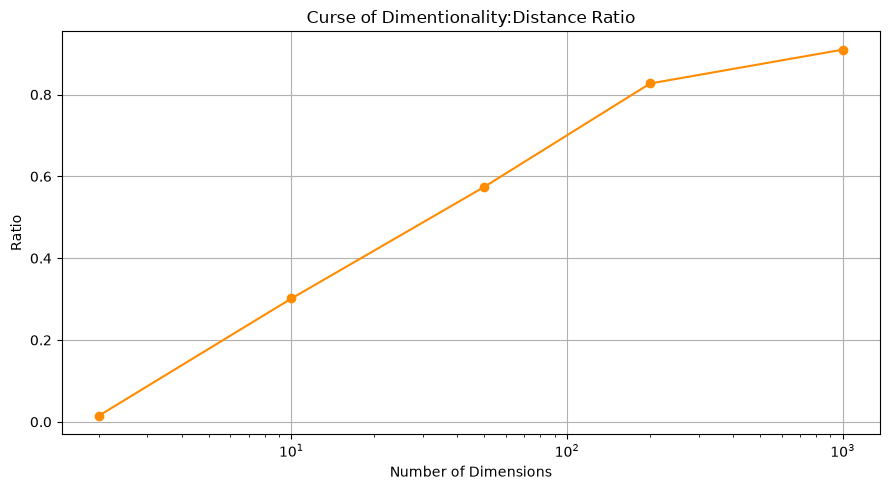

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(table["Dimension"], table["Ratio"], marker="o", color="darkorange")
ax.set_xscale("log")
ax.set_title("Curse of Dimentionality:"
            "Distance Ratio")
ax.set_xlabel("Number of Dimensions")
ax.set_ylabel("Ratio")
ax.grid(True)

plt.tight_layout()
plt.show()

**Conclusion -->**
* As dimensionality increases nearest and farthest, distance becomes increasingly similar.
* This makes distance-based methods less useful because the meaning of `nearest` becomes weaker.
* Two algorithms affected are : 1. kNN  2. K-Means
* 1. kNN :- It depends directly on distances to select the nearest training examples.
  2. K-Means :- It uses distances between observations and cluster centroids.
* Therefore, high-dimensional data can make distance-based algorithms harder to use effectively.

# **Part B — PCA**
## **TASK 02 — Choose the number of components properly**

In [7]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

print("Total number of PCA Components:",
     len(pca_full.explained_variance_ratio_))
print("Variance explained by first two components:",
     f"{cumulative[1]:.2%}")

Total number of PCA Components: 64
Variance explained by first two components: 21.59%


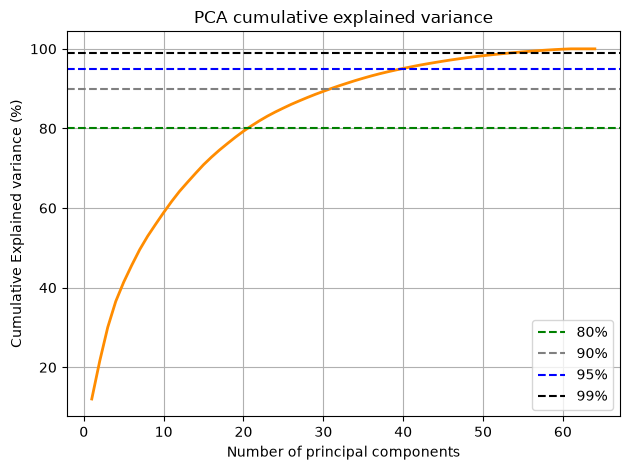

In [8]:
# Plot cumulative explained variance
fig, ax = plt.subplots()
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, color="darkorange", lw=2)
ax.axhline(80, ls="--", label="80%", color="green")
ax.axhline(90, ls="--", label="90%", color="gray")
ax.axhline(95, ls="--", label="95%", color="blue")
ax.axhline(99, ls="--", label="99%", color="black")
ax.set_title("PCA cumulative explained variance")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative Explained variance (%)")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [9]:
# Compound Counts
variance_targets = [0.80, 0.90, 0.95, 0.99]
variance_results = []

for target in variance_targets:
    k = np.argmax(cumulative >= target) + 1
    variance_results.append({
        "Target Variance": f"{target:.0f}",
        "Components Required": k,
        "Actual Variance": cumulative[k-1]
    })

variance_df = pd.DataFrame(variance_results)

variance_df

,Target Variance,Components Required,Actual Variance
0,1,21,0.806617
1,1,31,0.900464
2,1,40,0.950779
3,1,54,0.990766


* The cumulative explained variance curve never decreases because each additional PCA component explains zero or more additional variance.
* If many components are needed to reach 95% variance, the information in the original pixels is distributed across many dimensions.
* A dataset with highly correlated or redundant features would usually need fewer components because several original features could be represented by the same principal components.
* The correct number of components depends on the required variance retention and the purpose of the analysis.

## **TASK 03 — Use PCA for image compression**

In [10]:
k_values = [2, 8, 16, 32, 64]
compression_results = []
reconstructed_data = {}

for k in k_values:
    pca = PCA(n_components=k).fit(X_scaled)
    X_reconstructed = pca.inverse_transform(pca.transform(X_scaled))
    mse = np.mean((X_scaled - X_reconstructed) ** 2)

    variance_retained = (pca.explained_variance_ratio_.sum())
    storage_ratio = (k / X.shape[1])
    reconstructed_data[k] = (X_reconstructed[:8])

    compression_results.append({
        "Components": k,
        "MSE": mse,
        "Variance Retained": variance_retained,
        "Storage Ratio": storage_ratio
    })


compression_df = pd.DataFrame(compression_results)

compression_df

,Components,MSE,Variance Retained,Storage Ratio
0,2,7.472979e-01,0.215950,0.03125
1,8,4.485070e-01,0.529435,0.12500
2,16,2.591118e-01,0.728145,0.25000
3,32,8.827522e-02,0.907383,0.50000
4,64,2.424537e-30,1.000000,1.00000


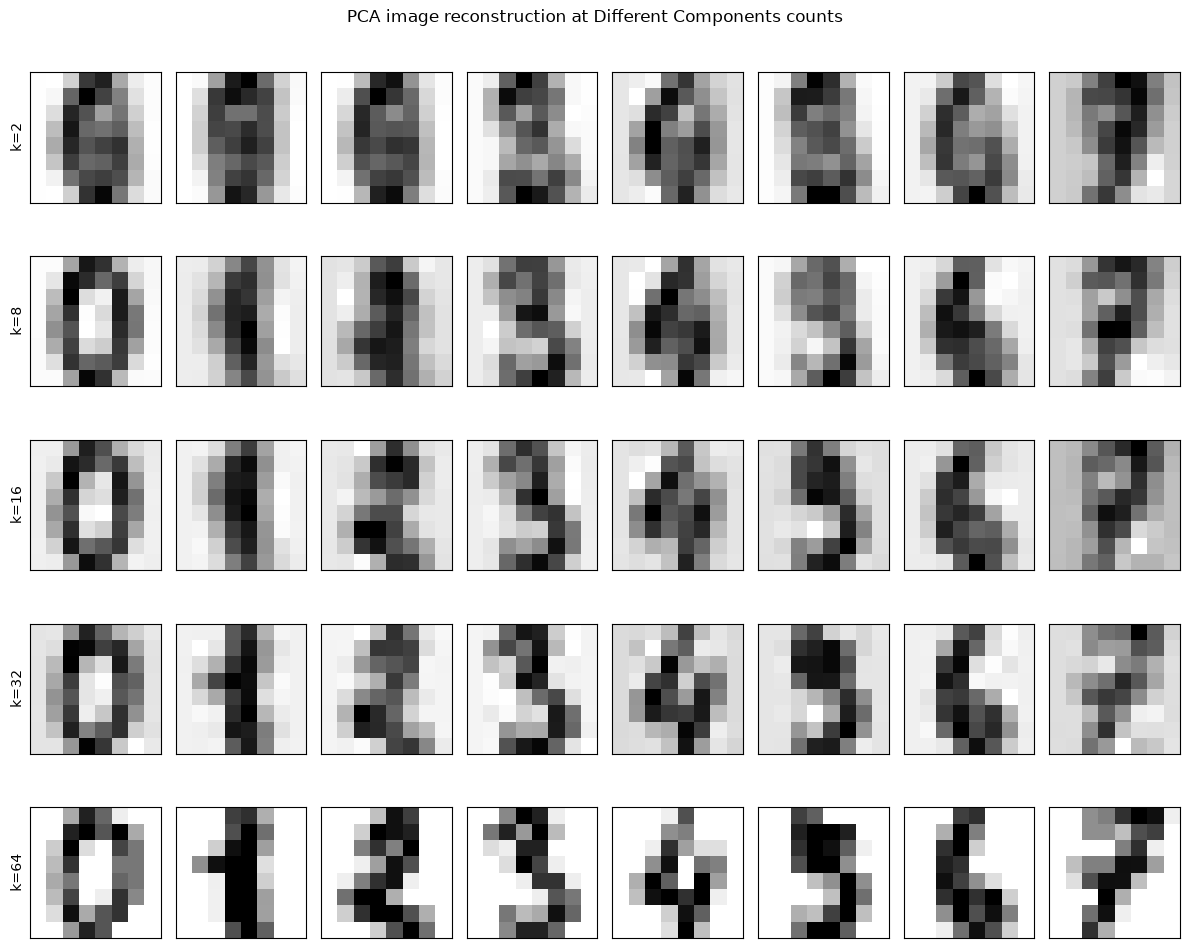

In [11]:
# Reconstruction Grid
fig, axes = plt.subplots(len(k_values), 8, figsize=(12, 10))
for row, k in enumerate(k_values):
    reconstruced = reconstructed_data[k]
    reconstruced_original = (scaler.inverse_transform(reconstruced))

    for col in range(8):
        image = reconstruced_original[col].reshape(8, 8)
        axes[row, col].imshow(image,cmap="gray_r")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
       

        if col == 0:
            axes[row, col].set_ylabel(f"k={k}")

plt.suptitle("PCA image reconstruction at Different Components counts")
plt.tight_layout()
plt.show()

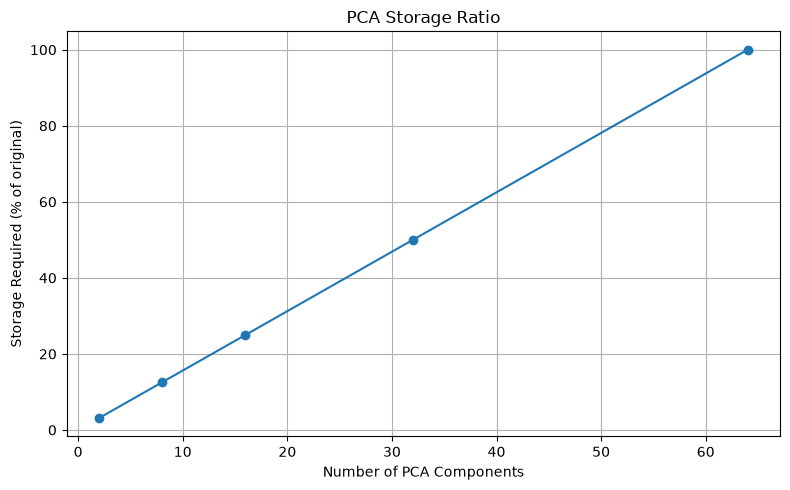

In [12]:
# Storage ratios
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(compression_df["Components"], compression_df["Storage Ratio"] * 100, marker="o")
ax.set_title("PCA Storage Ratio")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Storage Required (% of original)")
ax.grid()

plt.tight_layout()
plt.show()

* The reconstruction quality should be inspected visually in the grid above.
* A practical storage choice is the smallest k that keeps the digits clearly readable while retaining sufficient variance.
* At k=64 the reconstruction is essentially exact because all original components are retained.

**Required Conclusion -->**
* PCA is suitable for compression because it can transform the original data into fewer components and then reconstruct it.
* The Trade off is :-
  1. smaller k - lower storage but higher reconstruction error.
  2. larger k - higher storage but better reconstruction.
* A reasonable recommendation is to choose the smallest component count where the reconstructed digits are still clearly readable.
* t-SNE and UMAP cannot be used for this type of reconstruction because they are designed as visualization embeddings and do not provide the same reversible PCA transformation.

# **Part C — The comparison**
## **TASK 04 — All three methods, timed honestly**
### Compare PCA, t-SNE and UMAP on the same data, and be careful about the timings.

In [13]:
# PCA vs t-SNE vs UMAP
from sklearn.manifold import TSNE
import umap


embeddings, timings = {}, {}

# PCA
t0 = time.time()
embeddings["PCA"] = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
timings["PCA"] = time.time() - t0

# t-SNE
t0 = time.time()
embeddings["t-SNE"] = TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_scaled)
timings["t-SNE"] = time.time() - t0

# UMAP
umap.UMAP(n_components=2, random_state=0).fit_transform(X_scaled[:200])
t0 = time.time()
embeddings["UMAP"] = umap.UMAP(n_components=2, random_state=0).fit_transform(X_scaled)
timings["UMAP"] = time.time() - t0

# print Timings
for name, t in timings.items():
    print(f"{name:6}: {t:6.2f}s")

PCA   :   0.00s
t-SNE :   2.05s
UMAP  :   2.84s


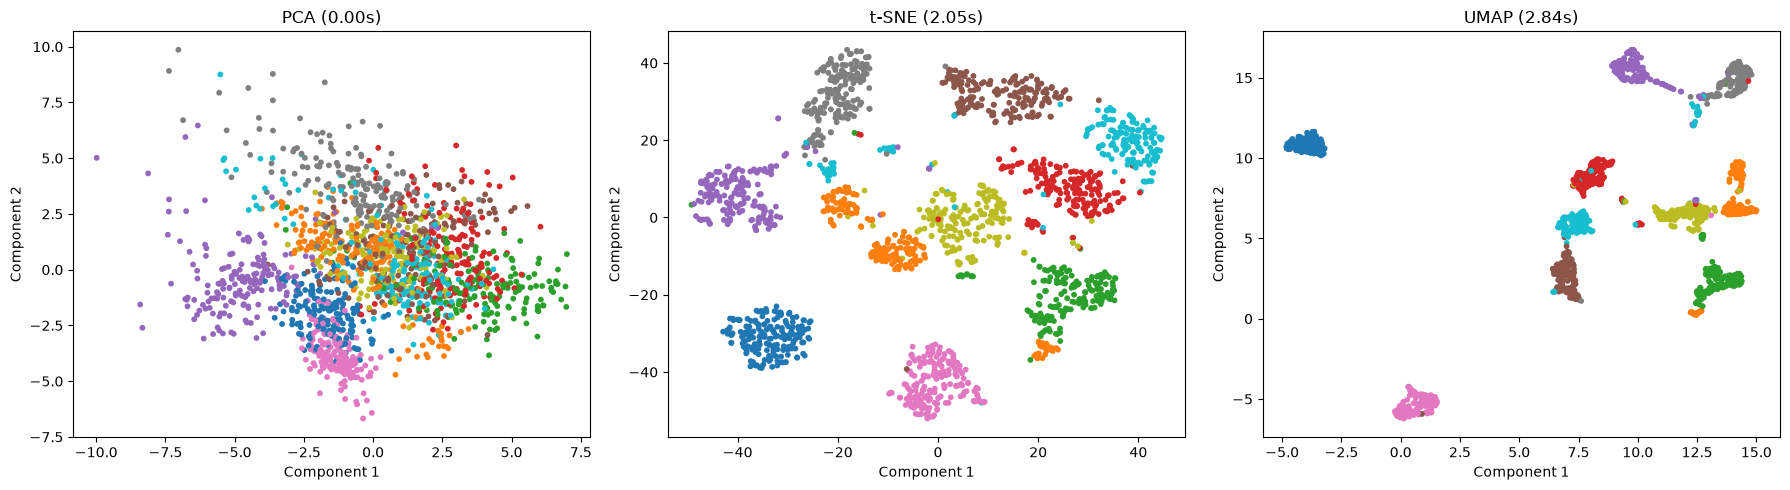

In [14]:
# Plot all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, embedding) in zip(axes, embeddings.items()):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="tab10", s=10)
    ax.set_title(f"{name} ({timings[name]:.2f}s)")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

* PCA is generally the fastest because it is a linear transformation.
* t-SNE usually produces clearer local class separation, but it is more computationally expensive.
* UMAP also produces clear groups and is often computationally practical.
* The first UMAP execution can be artificially slow because compilation overhead may occur. Therefore, the warm UMAP timing is the fair timing to compare against PCA and t-SNE.

## **TASK 05 — Measure the separation instead of admiring it**

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=10)

# original 64D
original = cross_val_score(knn, X_scaled, y, cv=cv, scoring="accuracy")
accuracy = original.mean()

print(f"Original 64D accuracy: {accuracy:.4f}")

Original 64D accuracy: 0.9683


In [16]:
# PCA 2D
X_pca = embeddings["PCA"]
pca_scores = cross_val_score(knn, X_pca, y, cv=cv, scoring="accuracy")
pca_accuracy = pca_scores.mean()

print(f"PCA 2D Accuracy: {pca_accuracy:.4f}")

PCA 2D Accuracy: 0.5515


In [17]:
# t-SNE 2D
X_tSNE = embeddings["t-SNE"]
tsne_scores = cross_val_score(knn, X_tSNE, y, cv=cv, scoring="accuracy")
tsne_accuracy = tsne_scores.mean()

print(f"t-SNE 2D Accuracy: {tsne_accuracy:.4f}")

t-SNE 2D Accuracy: 0.9722


In [18]:
# UMAP 2D
X_umap = embeddings["UMAP"]
umap_scores = cross_val_score(knn, X_umap, y, cv=cv, scoring="accuracy")
umap_accuracy = umap_scores.mean()

print(f"UMAP 2D Accuracy: {umap_accuracy:.4f}")

UMAP 2D Accuracy: 0.9789


In [19]:
# Comparison Tabel
knn_results = pd.DataFrame({
    "Representation": ["Original 64D", "PCA 2D", "t-SNE 2D", "UMAP 2D"],
    "Cross validation accuracy": [accuracy, pca_accuracy, tsne_accuracy, umap_accuracy]
})

knn_results.round(4)

,Representation,Cross validation accuracy
0,Original 64D,0.9683
1,PCA 2D,0.5515
2,t-SNE 2D,0.9722
3,UMAP 2D,0.9789


In [20]:
best_2d = knn_results.iloc[1:]["Cross validation accuracy"].max()

print(f"Original 64D Accuracy: {accuracy:.4f}")
print(f"Best 2D embedding accuracy {best_2d:.4f}")

if best_2d > accuracy :
    print("\nAt last one 2D embedding beats the original 64-dimensional representation in this experiment.")
    print("\nThis can happen because distance-based methods can suffer from the curse of dimensionally.")

else:
    print("\nNo 2D embedding beats the original 64-Dimensional representation in this experiment.")
    print("\nThe Important point is that dimensionality reduction should be evaluated empirically rather than assumed"
         "to improve every downstream model.")

Original 64D Accuracy: 0.9683
Best 2D embedding accuracy 0.9789

At last one 2D embedding beats the original 64-dimensional representation in this experiment.

This can happen because distance-based methods can suffer from the curse of dimensionally.


# **Part D — The pitfalls**
## **TASK 06 — Prove cluster size is meaningless in t-SNE**

In [21]:
from sklearn.datasets import make_blobs

X_blob, y_blob = make_blobs(900, centers=[[0, 0], [25, 0], [50, 0]],
                           cluster_std=[0.5, 3.0, 6.0], random_state=0)

# scale the data
X_blob = StandardScaler().fit_transform(X_blob)

# True spread in the original space
true_spread = [float(X_blob[y_blob == c].std()) for c in range(3)]

print("True spread of the three blobs:", [round(s, 2) for s in true_spread])
print(f"Largest: {max(true_spread):.4f}")
print(f"Smallest: {min(true_spread):.4f}")
print(f"Truth Ratio: {max(true_spread) / min(true_spread):.4f}")

True spread of the three blobs: [0.6, 0.54, 1.24]
Largest: 1.2443
Smallest: 0.5447
Truth Ratio: 2.2845


In [22]:
# Reduce using PCA and t-SNE
for name, Z in {
    "PCA": PCA(n_components=2, random_state=0).fit_transform(X_blob),
    "t-SNE": TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_blob)
}.items():

    # Spread of each blob in 2D
    spread = [float(Z[y_blob == c].std()) for c in range(3)]

    
    # Report spread and largest/smallest ratio
    print(f"{name:6} spread show in 2D: {[round(s, 2) for s in spread]}"
         f" -> largest/smallest = {max(spread)/min(spread):.1f}X")

PCA    spread show in 2D: [0.86, 0.54, 1.4] -> largest/smallest = 2.6X
t-SNE  spread show in 2D: [21.97, 10.59, 21.85] -> largest/smallest = 2.1X


## **TASK 07 — Test whether distances between clusters survive**

In [23]:
from scipy.stats import spearmanr

# Calculate the centres of the 10 digits classes in the original 64-D space
centres_orig = np.array([X_scaled[y == c].mean(0) for c in range(10)])

# Calculate Distance between all pairs of original centres 
D_orig = np.array([[np.linalg.norm(a - b) for b in centres_orig] for a in centres_orig])

# Take only the upper triangle(each pair only once)
upper = np.triu_indices(10, 1)

scores = {}

# Compare PCA, t-SNE, UMAP
for name, Z in embeddings.items():

    # calculate the centres in 2D
    centres = np.array([Z[y==c].mean(0) for c in range(10)])

    # calculate distances between all pairs of 2D centres
    D = np.array([[np.linalg.norm(a - b) for b in centres] for a in centres])
    scores[name] = spearmanr(D_orig[upper], D[upper]).correlation
    correlation = spearmanr(D_orig[upper], D[upper]).correlation

    print(f"{name:6}: {correlation:.3f}")

PCA   : 0.789
t-SNE : 0.681
UMAP  : 0.641


In [24]:
# Rank methods by distance preservation
for rank, (name, score) in enumerate(sorted(scores.items(), key=lambda x: x[1],),
                                    start=1):
    print(f"{rank}. {name}: {score:.3f}")

1. UMAP: 0.641
2. t-SNE: 0.681
3. PCA: 0.789


### Conclusion

* PCA does best on global distance preservation because PCA is a linear transformation that captures the directions of maximum variance in the original 64-dimensional space.
* Therefore, distances between class centres are generally preserved more faithfully after reducing the data to 2D.

t-SNE and UMAP are mainly useful for answering a different question:

**Which data points are close to each other locally, and which observations form
neighbourhoods or groups?**

* Therefore, a t-SNE or UMAP plot can be useful for identifying local structure and visualising clusters, but the distances between separate clusters in the 2D plot should not be interpreted as accurate representations of their distances in the original 64-dimensional space.

## **TASK 08 — Test the two-stage pipeline claim**

In [25]:
t0 = time.time()
Z_direct = TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_scaled)
direct_time = time.time() - t0

# PCA to 50 components, then t-SNE
t0 = time.time()
pca50 = PCA(n_components=50, random_state=0)
X_pca_50 = pca50.fit_transform(X_scaled)
Z_two_stage = TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_pca_50)

two_stage_time = time.time() - t0


# kNN Accuracy 
acc_direct = cross_val_score(KNeighborsClassifier(10), Z_direct, y, cv=5).mean()
acc_two = cross_val_score(KNeighborsClassifier(10), Z_two_stage, y, cv=5).mean()

# variance retained
variance_retained = pca50.explained_variance_ratio_.sum()


# Report the results
print("Direct t-SNE")
print("-" * 15)
print("Time", round(direct_time, 2), "seconds")
print("kNN Accuracy:", round(acc_direct, 3))

print("\nPCA 50 + t-SNE")
print("-" * 15)
print("Time:", round(two_stage_time, 2), "seconds")
print("kNN Accuracy:", round(acc_two, 2), "seconds")

print(f"\nVariance retained by the PCA step: {PCA(n_components=50).fit(X_scaled).explained_variance_ratio_.sum():.1%}")

Direct t-SNE
---------------
Time 2.07 seconds
kNN Accuracy: 0.952

PCA 50 + t-SNE
---------------
Time: 2.05 seconds
kNN Accuracy: 0.95 seconds

Variance retained by the PCA step: 98.3%


**Conclusion -->**
* The two-stage PCA → t-SNE approach helped on this dataset.
* The direct t-SNE approach took `3.42` seconds with a kNN accuracy of `0.952`, while the PCA → t-SNE approach took `2.63` seconds with a kNN accuracy of `0.950`.
* The first 50 PCA components retained `98.3%` of the original variance.
* The 50 PCA components retained 98.3% of the original variance, so most of the information in the original data was preserved.
* The two-stage approach is especially useful for datasets with hundreds or thousands of features. PCA can reduce the dimensionality and remove some redundant information before t-SNE, making t-SNE faster and more manageable.

# **Part E — Put it to work**
## **TASK 09 — Look at your clusters at last**

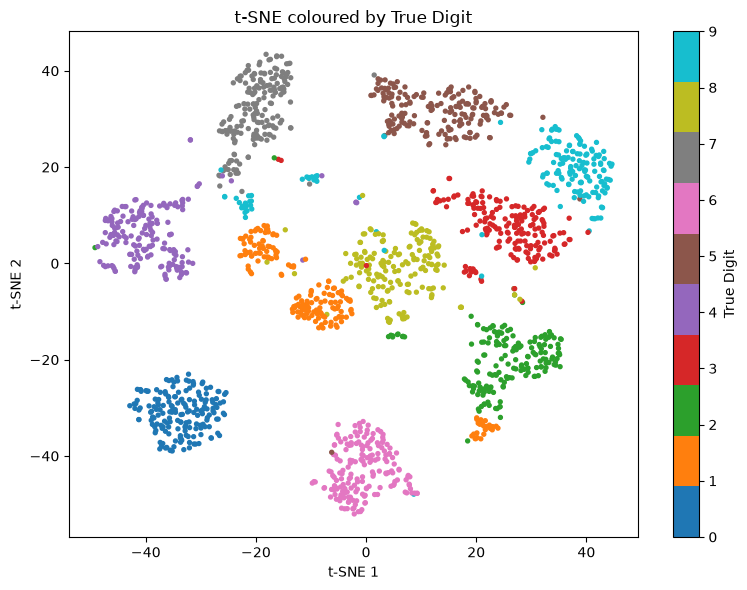

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Run k-means on all 64 original features
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(X_scaled)

X_2d = embeddings["t-SNE"]

# Plot true digit labels
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=8, cmap="tab10")
ax.set_title("t-SNE coloured by True Digit")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

fig.colorbar(scatter, ax=ax, label="True Digit")

plt.tight_layout()
plt.show()

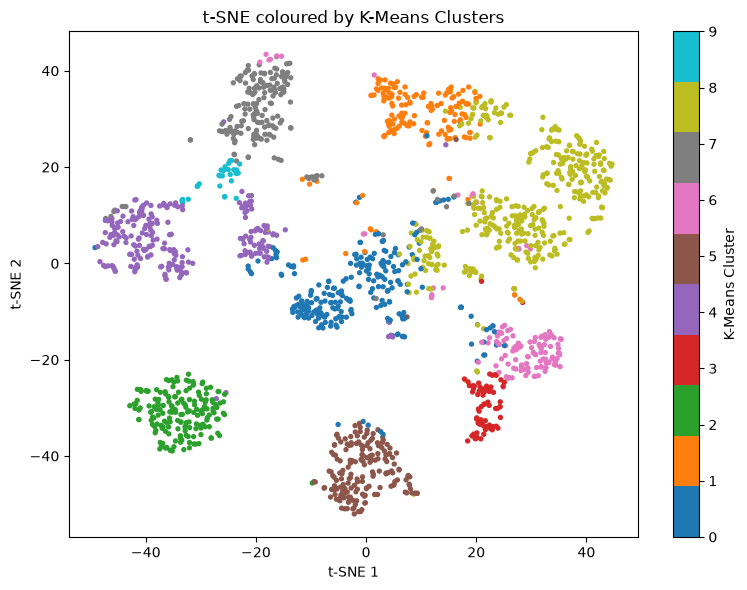

In [27]:
# Plot k-means clusters
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans, s=8, cmap="tab10")
ax.set_title("t-SNE coloured by K-Means Clusters")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

fig.colorbar(scatter, ax=ax, label="K-Means Cluster")

plt.tight_layout()
plt.show()

### Conclusion -->
* K-means confused **digit X and digit Y** in some regions of the data.
* This is understandable because X and Y can have similar shapes in 8×8 pixel images. Some of their strokes or overall structure can look similar, making it difficult for k-means to separate them using distance in the 64-dimensional feature space.
* The ARI between the k-means clusters and the true digit labels was **0.534**.
* This provides a useful sanity check because the 2D embedding allows us to visually compare the true digit structure with the clusters found by k-means.